In [1]:
from google.colab import files
uploaded = files.upload()


Saving german_credit_data.csv to german_credit_data.csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [10]:
df.rename(columns={
    'laufkont': 'Checking_Account_Status',
    'laufzeit': 'Loan_Duration',
    'moral': 'Credit_History',
    'verw': 'Loan_Purpose',
    'hoehe': 'Credit_Amount',
    'sparkont': 'Savings_Account',
    'beszeit': 'Employment_Duration',
    'rate': 'Installment_Rate',
    'famges': 'Personal_Status_Sex',
    'buerge': 'Guarantor',
    'weitkred': 'Other_Installment_Plans',
    'wohn': 'Housing',
    'bishkred': 'Existing_Credits',
    'beruf': 'Job',
    'pers': 'Number_of_People_Liable',
    'telef': 'Telephone',
    'gastarb': 'Foreign_Worker',
    'verm': 'Property',
    'alter': 'Age',
    'kredit': 'Risk'
}, inplace=True)

In [11]:
print(df.columns)

Index(['Checking_Account_Status', 'Duration', 'Credit_History', 'Loan_Purpose',
       'Credit_Amount', 'Savings_Account', 'Employment_Duration',
       'Installment_Rate', 'Personal_Status_Sex', 'Guarantor', 'wohnzeit',
       'Property', 'Age', 'Other_Installment_Plans', 'Housing',
       'Existing_Credits', 'Job', 'Number_of_People_Liable', 'Telephone',
       'Foreign_Worker', 'Risk', 'debt_income_ratio', 'credit_per_duration'],
      dtype='object')


In [12]:
df['debt_income_ratio'] = df['Credit_Amount'] / (df['Age'] + 1)
df['credit_per_duration'] = df['Credit_Amount'] / (df['Duration'] + 1)

In [13]:
X = df.drop('Risk', axis=1)
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [16]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [17]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [18]:
models = {'Logistic': lr, 'Decision Tree': dt, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))


Logistic Results:
Accuracy: 0.76
Precision: 0.7884615384615384
Recall: 0.8913043478260869
F1 Score: 0.8367346938775511
ROC-AUC: 0.679523141654979

Decision Tree Results:
Accuracy: 0.695
Precision: 0.808
Recall: 0.7318840579710145
F1 Score: 0.7680608365019012
ROC-AUC: 0.6723936418887332

Random Forest Results:
Accuracy: 0.79
Precision: 0.8157894736842105
Recall: 0.8985507246376812
F1 Score: 0.8551724137931035
ROC-AUC: 0.7234689107059373


In [19]:
import joblib
joblib.dump(rf, "credit_model.pkl")

['credit_model.pkl']

In [20]:
from google.colab import files
files.download("credit_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

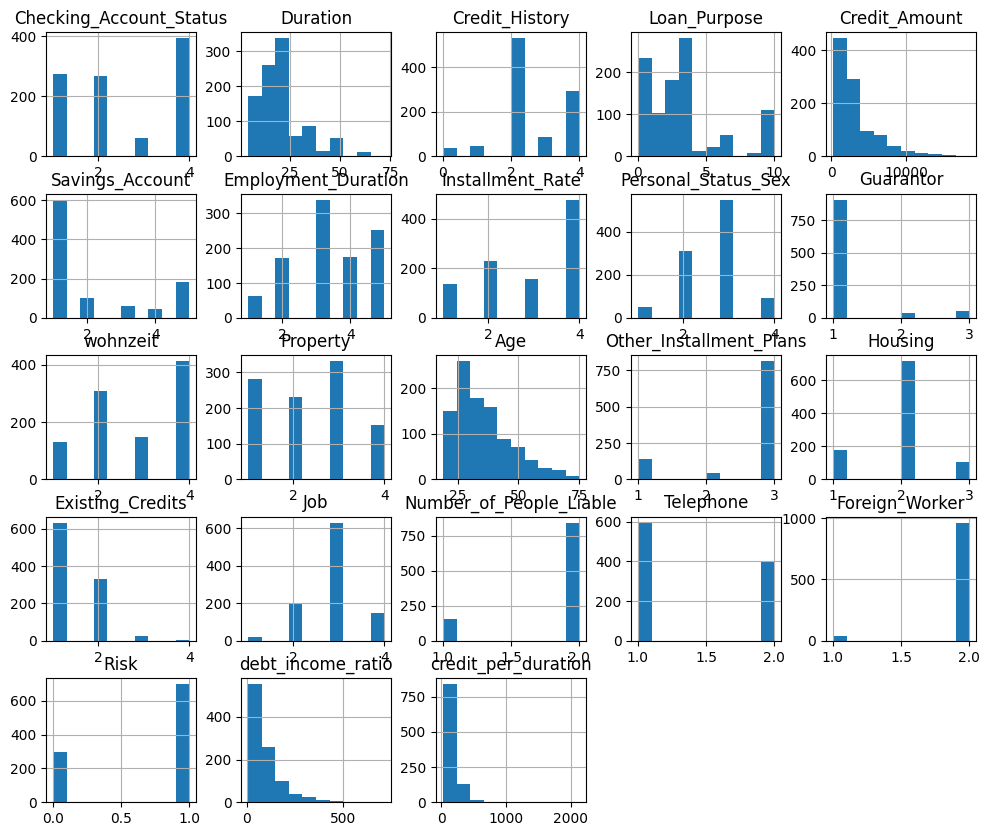

In [23]:
df.hist(figsize=(12,10))
plt.show()

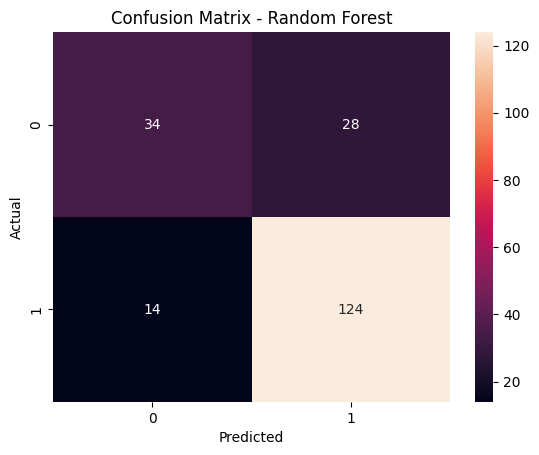

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()